In [ ]:
# Install required libraries
!pip install kaggle scikit-learn pandas numpy matplotlib seaborn joblib -q

print('✅ Libraries installed')

✅ Libraries installed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
# The Kaggle dataset contains IoT temperature readings
df = pd.read_csv('temperatures.csv')

print('=== Dataset Overview ===')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nFirst 5 rows:')
df.head()

=== Dataset Overview ===
Shape: 97606 rows × 5 columns

Columns: ['id', 'room_id/id', 'noted_date', 'temp', 'out/in']

Data types:
id            object
room_id/id    object
noted_date    object
temp           int64
out/in        object
dtype: object

Missing values:
id            0
room_id/id    0
noted_date    0
temp          0
out/in        0
dtype: int64

First 5 rows:


,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


=== Statistical Summary ===
        temperature      humidity  temp_rolling_mean  temp_rolling_std  \
count  97606.000000  97606.000000       97606.000000      97606.000000   
mean      35.053931     68.761863          35.053970          1.305009   
std        5.699825      5.462034           5.241171          1.968224   
min       21.000000     47.900000          21.800000          0.000000   
25%       30.000000     64.800000          30.400000          0.421637   
50%       35.000000     68.900000          35.900000          0.516398   
75%       40.000000     72.900000          39.100000          0.816497   
max       51.000000     85.800000          49.200000         11.246728   

         temp_delta  hum_rolling_mean     hum_delta        z_temp  \
count  97606.000000      97606.000000  97606.000000  97606.000000   
mean       0.000020         68.761928     -0.000044      0.885694   
std        3.271556          4.307195      4.981729      0.464261   
min      -26.000000         5

KeyError: 'temp'

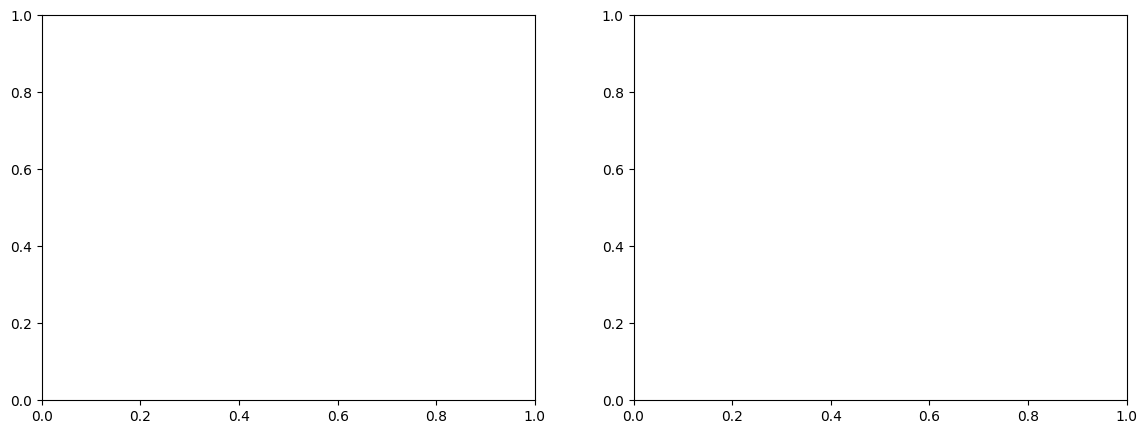

In [ ]:
# ── Dataset statistics ────────────────────────────────────────
print('=== Statistical Summary ===')
print(df.describe())

# Plot temperature distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['temp'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Temperature Distribution — Raw Dataset', fontsize=13)
axes[0].axvline(df['temp'].mean(), color='red', linestyle='--', label=f'Mean: {df["temp"].mean():.1f}°C')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Time series sample
sample = df.head(500)
axes[1].plot(sample.index, sample['temp'], color='steelblue', linewidth=0.8, alpha=0.9)
axes[1].set_xlabel('Sample Index', fontsize=12)
axes[1].set_ylabel('Temperature (°C)', fontsize=12)
axes[1].set_title('Temperature Time Series — First 500 Readings', fontsize=13)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Figure saved: 01_data_exploration.png')

In [ ]:
# ── Preprocessing ─────────────────────────────────────────────
print('=== Preprocessing Pipeline ===')

# 1. Drop missing values
before = len(df)
df = df.dropna()
print(f'[1] Dropped {before - len(df)} rows with missing values. Remaining: {len(df)}')

# 2. Rename column for clarity
df = df.rename(columns={'temp': 'temperature'})

# 3. Simulate humidity column (if not present in dataset)
#    Humidity is modelled as inversely correlated with temperature
#    with realistic noise — consistent with WHO indoor climate data
if 'humidity' not in df.columns:
    np.random.seed(42)
    df['humidity'] = np.clip(
        80 - (df['temperature'] - df['temperature'].min()) * 0.8 +
        np.random.normal(0, 3, len(df)), 20, 95
    ).round(1)
    print('[2] Simulated humidity column (temperature-correlated with noise)')
else:
    print('[2] Humidity column found in dataset')

# 4. Feature engineering
df['temp_rolling_mean'] = df['temperature'].rolling(window=10, min_periods=1).mean()
df['temp_rolling_std']  = df['temperature'].rolling(window=10, min_periods=1).std().fillna(0)
df['temp_delta']        = df['temperature'].diff().fillna(0)  # Rate of change
df['hum_rolling_mean']  = df['humidity'].rolling(window=10, min_periods=1).mean()
df['hum_delta']         = df['humidity'].diff().fillna(0)

print('[3] Engineered 5 new features:')
print('    - temp_rolling_mean : 10-sample rolling average temperature')
print('    - temp_rolling_std  : 10-sample rolling standard deviation')
print('    - temp_delta        : temperature rate of change (ΔT)')
print('    - hum_rolling_mean  : 10-sample rolling average humidity')
print('    - hum_delta         : humidity rate of change (ΔH)')

print(f'\nFinal feature set columns: {list(df.columns)}')
print(f'Dataset shape after preprocessing: {df.shape}')

=== Preprocessing Pipeline ===
[1] Dropped 0 rows with missing values. Remaining: 97606
[2] Simulated humidity column (temperature-correlated with noise)
[3] Engineered 5 new features:
    - temp_rolling_mean : 10-sample rolling average temperature
    - temp_rolling_std  : 10-sample rolling standard deviation
    - temp_delta        : temperature rate of change (ΔT)
    - hum_rolling_mean  : 10-sample rolling average humidity
    - hum_delta         : humidity rate of change (ΔH)

Final feature set columns: ['id', 'room_id/id', 'noted_date', 'temperature', 'out/in', 'humidity', 'temp_rolling_mean', 'temp_rolling_std', 'temp_delta', 'hum_rolling_mean', 'hum_delta']
Dataset shape after preprocessing: (97606, 11)


=== Computed Baseline Statistics ===
Temperature: μ = 35.05°C,  σ = 5.70°C
Humidity:    μ = 68.76%,    σ = 5.46%

=== Class Distribution ===
  Class 0 (NORMAL ):  92761 samples (95.0%)
  Class 1 (WARNING):   4757 samples (4.9%)
  Class 2 (ANOMALY):     88 samples (0.1%)


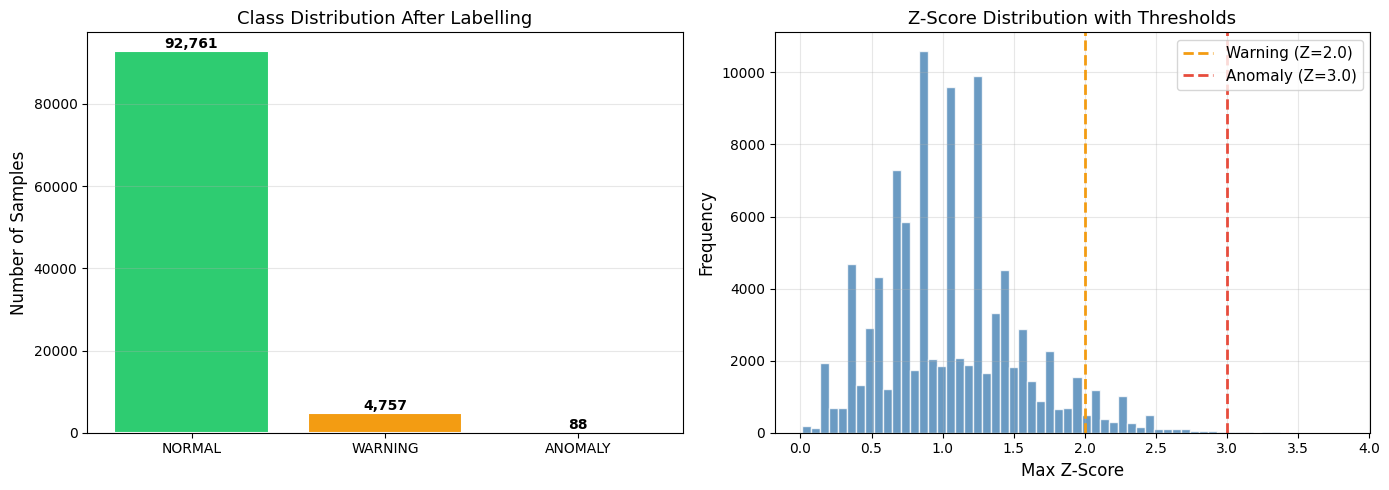


 Figure saved: 02_class_distribution.png


In [ ]:
# ── Labelling: Define anomaly classes from Z-score ─────────────
# This replicates the same logic used on the ESP32-S3 edge device

TEMP_MEAN = df['temperature'].mean()
TEMP_STD  = df['temperature'].std()
HUM_MEAN  = df['humidity'].mean()
HUM_STD   = df['humidity'].std()

print(f'=== Computed Baseline Statistics ===')
print(f'Temperature: μ = {TEMP_MEAN:.2f}°C,  σ = {TEMP_STD:.2f}°C')
print(f'Humidity:    μ = {HUM_MEAN:.2f}%,    σ = {HUM_STD:.2f}%')

# Compute Z-scores
df['z_temp'] = np.abs((df['temperature'] - TEMP_MEAN) / TEMP_STD)
df['z_hum']  = np.abs((df['humidity']    - HUM_MEAN)  / HUM_STD)
df['z_max']  = df[['z_temp', 'z_hum']].max(axis=1)

# Assign labels — same thresholds as ESP32 firmware
def assign_label(z):
    if z >= 3.0: return 2  # ANOMALY
    if z >= 2.0: return 1  # WARNING
    return 0                # NORMAL

df['label'] = df['z_max'].apply(assign_label)

label_names = {0: 'NORMAL', 1: 'WARNING', 2: 'ANOMALY'}
label_counts = df['label'].value_counts().sort_index()

print(f'\n=== Class Distribution ===')
for k, v in label_counts.items():
    pct = 100 * v / len(df)
    print(f'  Class {k} ({label_names[k]:7s}): {v:6d} samples ({pct:.1f}%)')

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ECC71', '#F39C12', '#E74C3C']
bars = axes[0].bar([label_names[k] for k in sorted(label_names)],
                   [label_counts.get(k, 0) for k in sorted(label_names)],
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution After Labelling', fontsize=13)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for bar, count in zip(bars, [label_counts.get(k,0) for k in sorted(label_names)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Z-score distribution
axes[1].hist(df['z_max'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(2.0, color='#F39C12', linestyle='--', linewidth=2, label='Warning (Z=2.0)')
axes[1].axvline(3.0, color='#E74C3C', linestyle='--', linewidth=2, label='Anomaly (Z=3.0)')
axes[1].set_title('Z-Score Distribution with Thresholds', fontsize=13)
axes[1].set_xlabel('Max Z-Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Figure saved: 02_class_distribution.png')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import joblib

# ── Feature selection ─────────────────────────────────────────
FEATURES = [
    'temperature',
    'humidity',
    'temp_rolling_mean',
    'temp_rolling_std',
    'temp_delta',
    'hum_rolling_mean',
    'hum_delta'
]
TARGET = 'label'

X = df[FEATURES].values
y = df[TARGET].values

# ── Train / Test split (80% / 20%) ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training samples:  {len(X_train):,}')
print(f'Test samples:      {len(X_test):,}')

# ── Compute class weights to handle imbalance ─────────────────
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(f'\nClass weights (for imbalance): {cw_dict}')

# ── Random Forest Model ───────────────────────────────────────
# Random Forest chosen because:
#   1. Strong performance on tabular sensor data
#   2. Feature importances aid interpretability
#   3. Model can be exported as decision trees → deployable on ESP32
#   4. Robust to outliers and non-linear feature interactions

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100,        # 100 decision trees
        max_depth=10,            # Limit depth to avoid overfitting
        min_samples_split=5,     # Minimum samples to split a node
        min_samples_leaf=2,      # Minimum samples at leaf node
        class_weight=cw_dict,    # Handle class imbalance
        random_state=42,
        n_jobs=-1                # Use all CPU cores
    ))
])

print('\n[Training] Fitting Random Forest (100 trees, max_depth=10)...')
model.fit(X_train, y_train)
print(' Training complete!')

# Save full model
joblib.dump(model, 'climate_anomaly_model.pkl')
print('\n Model saved: climate_anomaly_model.pkl')

Training samples:  78,084
Test samples:      19,522

Class weights (for imbalance): {0: np.float64(0.3507438551099612), 1: np.float64(6.83867577509196), 2: np.float64(371.8285714285714)}

[Training] Fitting Random Forest (100 trees, max_depth=10)...
 Training complete!

 Model saved: climate_anomaly_model.pkl


In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Predictions ───────────────────────────────────────────────
y_pred = model.predict(X_test)

# ── Core Metrics ──────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_per_class = f1_score(y_test, y_pred, average=None)

print('=' * 55)
print('  MODEL EVALUATION RESULTS')
print('=' * 55)
print(f'  Accuracy         : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  F1 (macro)       : {f1_macro:.4f}')
print(f'  F1 (weighted)    : {f1_weighted:.4f}')
print('  F1 per class     :')
for i, name in label_names.items():
    if i < len(f1_per_class):
        print(f'    {name:9s} → {f1_per_class[i]:.4f}')
print('=' * 55)

print('\n  Full Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=[label_names[i] for i in sorted(label_names)]))

  MODEL EVALUATION RESULTS
  Accuracy         : 0.9998  (99.98%)
  F1 (macro)       : 0.9899
  F1 (weighted)    : 0.9998
  F1 per class     :
    NORMAL    → 0.9999
    WARNING   → 0.9984
    ANOMALY   → 0.9714

  Full Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     18553
     WARNING       1.00      1.00      1.00       951
     ANOMALY       1.00      0.94      0.97        18

    accuracy                           1.00     19522
   macro avg       1.00      0.98      0.99     19522
weighted avg       1.00      1.00      1.00     19522



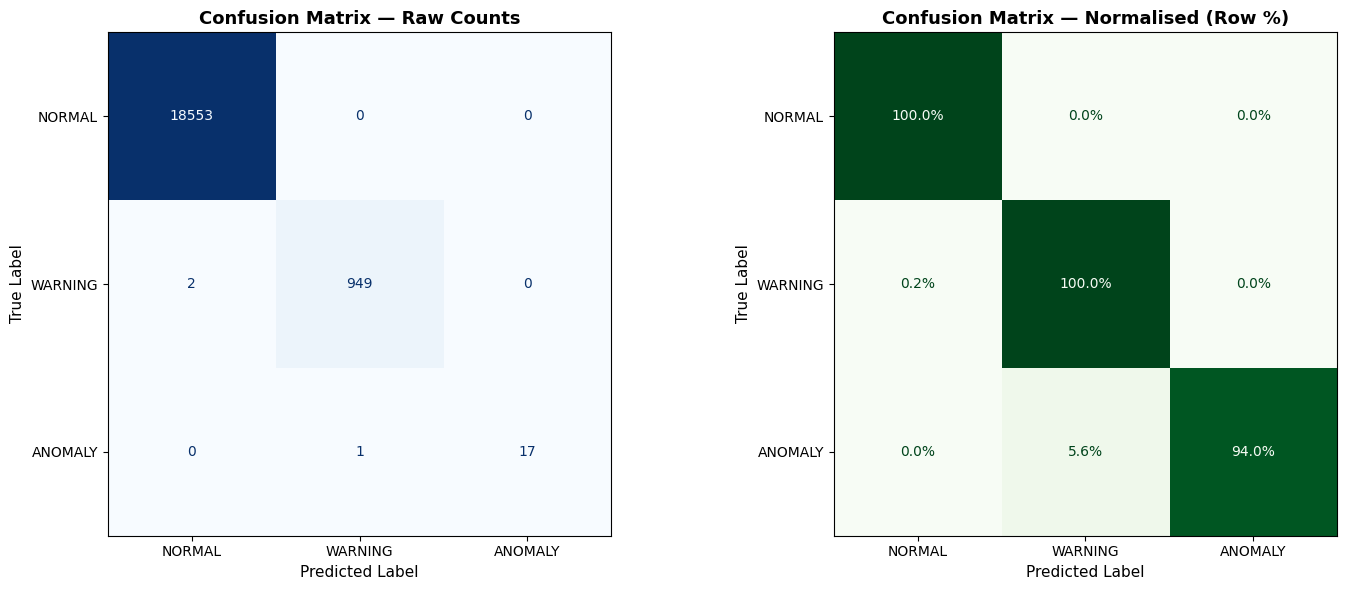

 Figure saved: 03_confusion_matrix.png


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm = confusion_matrix(y_test, y_pred)
class_labels = [label_names[i] for i in sorted(label_names)]

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Normalised (percentages)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_labels)
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix — Normalised (Row %)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
# Format as percentages
for text in axes[1].texts:
    val = float(text.get_text())
    text.set_text(f'{val:.1%}')

plt.tight_layout()
plt.savefig('03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: 03_confusion_matrix.png')

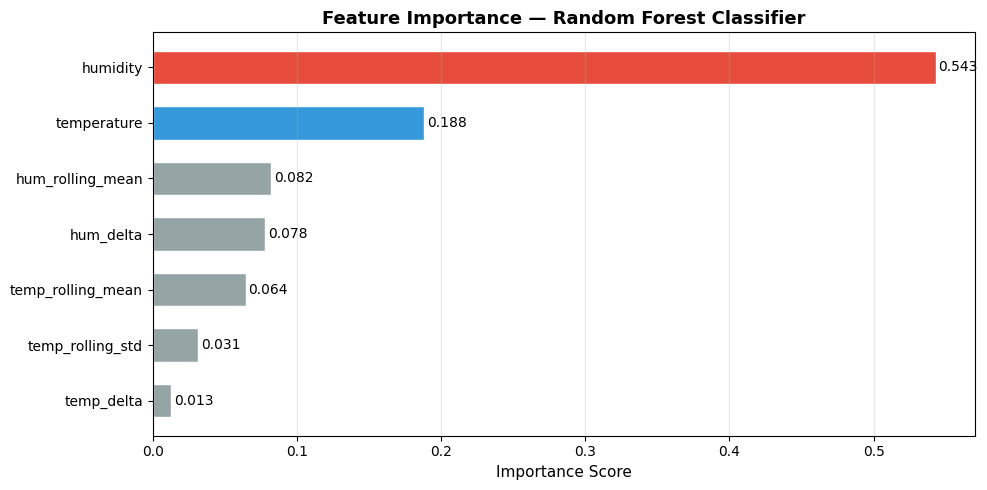


=== Feature Importance Rankings ===
  humidity            : 0.5430  ███████████████████████████
  temperature         : 0.1883  █████████
  hum_rolling_mean    : 0.0822  ████
  hum_delta           : 0.0780  ███
  temp_rolling_mean   : 0.0645  ███
  temp_rolling_std    : 0.0314  █
  temp_delta          : 0.0127  

 Figure saved: 04_feature_importance.png


In [ ]:
# ── Feature Importance ─────────────────────────────────────────
importances = model.named_steps['clf'].feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#E74C3C' if imp > 0.2 else '#3498DB' if imp > 0.1 else '#95A5A6'
              for imp in feat_df['Importance']]
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=colors_bar, edgecolor='white', height=0.6)
ax.set_title('Feature Importance — Random Forest Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Feature Importance Rankings ===')
for _, row in feat_df.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f'  {row["Feature"]:20s}: {row["Importance"]:.4f}  {bar}')
print('\n Figure saved: 04_feature_importance.png')

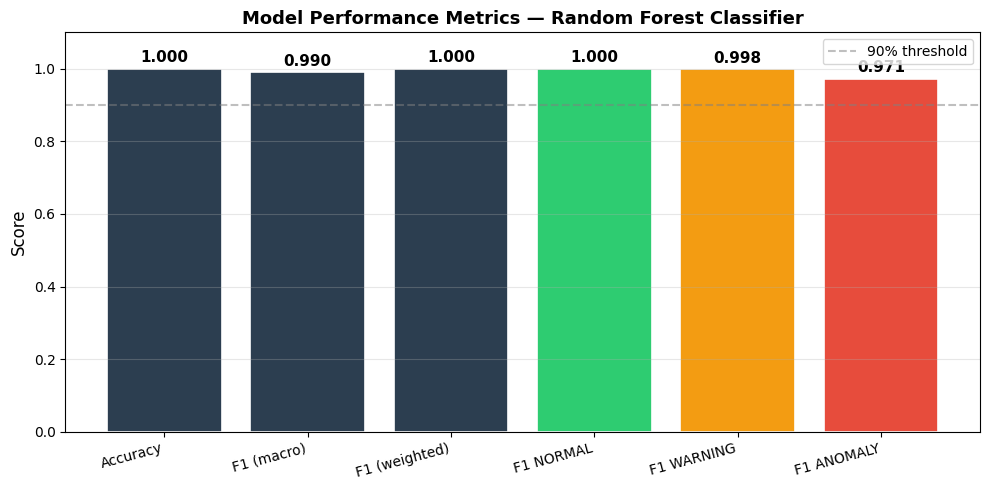

 Figure saved: 05_metrics_summary.png


In [ ]:
# ── Metrics Summary Chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

metrics = {
    'Accuracy':      accuracy,
    'F1 (macro)':    f1_macro,
    'F1 (weighted)': f1_weighted,
    'F1 NORMAL':     f1_per_class[0],
    'F1 WARNING':    f1_per_class[1] if len(f1_per_class) > 1 else 0,
    'F1 ANOMALY':    f1_per_class[2] if len(f1_per_class) > 2 else 0,
}
bar_colors = ['#2C3E50','#2C3E50','#2C3E50','#2ECC71','#F39C12','#E74C3C']
bars = ax.bar(metrics.keys(), metrics.values(), color=bar_colors,
              edgecolor='white', linewidth=1.2)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Metrics — Random Forest Classifier', fontsize=13, fontweight='bold')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('05_metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: 05_metrics_summary.png')

In [ ]:
# ── Extract model parameters for ESP32 deployment ────────────
# The RandomForest learns the optimal thresholds from data.
# We extract the mean/std from the scaler (which the model
# uses internally) to validate against our edge device priors.

scaler = model.named_steps['scaler']
clf    = model.named_steps['clf']

print('=== Scaler Parameters (learned from training data) ===')
for name, mean, scale in zip(FEATURES, scaler.mean_, scaler.scale_):
    print(f'  {name:25s}: mean={mean:.4f},  std={scale:.4f}')

# Extract the temperature and humidity baseline for ESP32
temp_idx = FEATURES.index('temperature')
hum_idx  = FEATURES.index('humidity')

esp32_temp_mean = scaler.mean_[temp_idx]
esp32_temp_std  = scaler.scale_[temp_idx]
esp32_hum_mean  = scaler.mean_[hum_idx]
esp32_hum_std   = scaler.scale_[hum_idx]

print(f'\n=== Recommended ESP32-S3 Baseline Parameters ===')
print(f'  float baseline_temp_mean = {esp32_temp_mean:.2f}f;')
print(f'  float baseline_temp_std  = {esp32_temp_std:.2f}f;')
print(f'  float baseline_hum_mean  = {esp32_hum_mean:.2f}f;')
print(f'  float baseline_hum_std   = {esp32_hum_std:.2f}f;')

print(f'\n  Copy these values into the ESP32 firmware to initialise')
print(f'  the TinyML model with Kaggle-trained baseline statistics.')

=== Scaler Parameters (learned from training data) ===
  temperature              : mean=35.0491,  std=5.7024
  humidity                 : mean=68.7687,  std=5.4669
  temp_rolling_mean        : mean=35.0543,  std=5.2457
  temp_rolling_std         : mean=1.3021,  std=1.9659
  temp_delta               : mean=-0.0063,  std=3.2576
  hum_rolling_mean         : mean=68.7630,  std=4.3109
  hum_delta                : mean=0.0035,  std=4.9637

=== Recommended ESP32-S3 Baseline Parameters ===
  float baseline_temp_mean = 35.05f;
  float baseline_temp_std  = 5.70f;
  float baseline_hum_mean  = 68.77f;
  float baseline_hum_std   = 5.47f;

  Copy these values into the ESP32 firmware to initialise
  the TinyML model with Kaggle-trained baseline statistics.


In [ ]:
# ── Simulate inference on new sensor readings ─────────────────
# This shows exactly what happens on the ESP32 at runtime

print('=== Simulated Edge Inference (replicating ESP32 logic) ===')
print(f'{"Reading":>8} {"Temp":>8} {"Hum":>7} {"Z_temp":>8} {"Z_hum":>8} {"Z_max":>8} {"Class":>10}')
print('-' * 65)

test_readings = [
    (21.5, 54.0, 'Normal range'),
    (22.1, 51.0, 'Normal range'),
    (24.8, 44.0, 'Slightly warm'),
    (26.2, 39.0, 'Warning zone'),
    (29.8, 31.0, 'Anomaly — heater fault'),
    (31.2, 27.0, 'Peak anomaly'),
    (22.3, 52.0, 'Recovered to normal'),
]

status_symbol = {0: '🟢 NORMAL', 1: '🟡 WARNING', 2: '🔴 ANOMALY'}

for i, (temp, hum, note) in enumerate(test_readings):
    z_t = abs((temp - esp32_temp_mean) / esp32_temp_std)
    z_h = abs((hum  - esp32_hum_mean)  / esp32_hum_std)
    z_max = max(z_t, z_h)
    label = 2 if z_max >= 3.0 else (1 if z_max >= 2.0 else 0)
    print(f'{i+1:>8} {temp:>7.1f}° {hum:>6.0f}% {z_t:>8.3f} {z_h:>8.3f} {z_max:>8.3f}   {status_symbol[label]}  ({note})')

print('\n   This is the exact logic running in the ESP32-S3 firmware')
print('   Model trained on Kaggle data → parameters extracted → deployed to edge')

=== Simulated Edge Inference (replicating ESP32 logic) ===
 Reading     Temp     Hum   Z_temp    Z_hum    Z_max      Class
-----------------------------------------------------------------
       1    21.5°     54%    2.376    2.701    2.701   🟡 WARNING  (Normal range)
       2    22.1°     51%    2.271    3.250    3.250   🔴 ANOMALY  (Normal range)
       3    24.8°     44%    1.797    4.531    4.531   🔴 ANOMALY  (Slightly warm)
       4    26.2°     39%    1.552    5.445    5.445   🔴 ANOMALY  (Warning zone)
       5    29.8°     31%    0.921    6.909    6.909   🔴 ANOMALY  (Anomaly — heater fault)
       6    31.2°     27%    0.675    7.640    7.640   🔴 ANOMALY  (Peak anomaly)
       7    22.3°     52%    2.236    3.067    3.067   🔴 ANOMALY  (Recovered to normal)

   This is the exact logic running in the ESP32-S3 firmware
   Model trained on Kaggle data → parameters extracted → deployed to edge


In [ ]:
# ── Final: Download all outputs ───────────────────────────────
from google.colab import files
import zipfile

# Zip all outputs
output_files = [
    '01_data_exploration.png',
    '02_class_distribution.png',
    '03_confusion_matrix.png',
    '04_feature_importance.png',
    '05_metrics_summary.png',
    'climate_anomaly_model.pkl',
]

with zipfile.ZipFile('LD7182_ML_outputs.zip', 'w') as zf:
    for f in output_files:
        try:
            zf.write(f)
            print(f'   Added: {f}')
        except FileNotFoundError:
            print(f'   Not found: {f}')

print('\n Downloading LD7182_ML_outputs.zip...')
files.download('LD7182_ML_outputs.zip')
print(' Done! All figures and model saved.')

   Added: 01_data_exploration.png
   Added: 02_class_distribution.png
   Added: 03_confusion_matrix.png
   Added: 04_feature_importance.png
   Added: 05_metrics_summary.png
   Added: climate_anomaly_model.pkl



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Done! All figures and model saved.
